## KNN Regression Data (NO₂ Surabaya)
K-Nearest Neighbors (KNN) Regression merupakan salah satu algoritma dalam machine learning yang melakukan prediksi berdasarkan kemiripan antara data baru dengan beberapa data historis. Dalam proses prediksi, algoritma ini akan mencari K data terdekat (nearest neighbors) kemudian menghitung rata-rata dari nilai target pada data-data tersebut untuk menghasilkan nilai prediksi.

Dalam konteks prediksi konsentrasi NO₂, nilai lag (misalnya NO₂ dua hingga lima hari sebelumnya) digunakan sebagai fitur yang merepresentasikan kondisi historis. KNN kemudian mencari periode masa lalu dengan pola lag yang mirip, dan memprediksi kadar NO₂ pada hari berikutnya berdasarkan rata-rata kadar NO₂ dari periode-periode yang serupa tersebut.

## Mengapa R-Squared dan MSE Rendah pada Eksperimen?
Nilai R-Squared yang rendah mengindikasikan bahwa variasi kadar NO₂ pada hari berikutnya tidak dapat dijelaskan sepenuhnya hanya dengan menggunakan data lag 2–5 hari sebelumnya. Hal ini wajar terjadi karena model belum mempertimbangkan faktor lingkungan lain yang berpengaruh besar terhadap kadar NO₂, seperti suhu, kelembapan, atau intensitas lalu lintas. Akibatnya, model KNN hanya mampu memperkirakan berdasarkan pola historis yang terbatas.

## Modeling Data NO₂ Surabaya
Proses pemodelan ini dilakukan sesuai dengan eksperimen supervised learning, menggunakan data lag antara dua hingga lima hari sebelumnya sebagai fitur untuk memprediksi kadar NO₂ pada hari berikutnya.

# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Membaca Dokumen

In [2]:
import pandas as pd

# Baca file hasil interpolasi (yang sudah dibersihkan)
df = pd.read_csv("no2_results_surabaya/timeseries_cleaned.csv")

# Cek 5 baris pertama
print(df.head())


         date       NO2
0  2020-06-15  0.000045
1  2020-06-14  0.000040
2  2020-06-13  0.000035
3  2020-06-16  0.000023
4  2020-06-17  0.000029


## Modeling Data t1, t2

In [3]:


# Baca data supervised
data = pd.read_csv("no2_results_surabaya/no2_surabaya_supervised.csv")

# Jika ada kolom tanggal, buang
if 'date' in data.columns:
    data = data.drop(columns=['date'])

# Pisahkan fitur dan target
X = data.drop(columns=['NO2'])
y = data['NO2']

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisasi data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model KNN
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Prediksi
y_pred = knn.predict(X_test_scaled)

# Evaluasi
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)


MSE: 1.2318080881918073e-10
R2: 0.35460516739430537


# Modeling Data t1, t2, t3

In [4]:
# Baca data hasil supervised learning
df = pd.read_csv("no2_results_surabaya/no2_surabaya_supervised.csv")

# Hapus kolom tanggal jika ada
if 'date' in df.columns:
    df = df.drop(columns=['date'])

# Pisahkan fitur (X) dan target (y)
X = df.drop(columns=['NO2'])
y = df['NO2']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model KNN Regression
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Prediksi dan evaluasi
y_pred = knn.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📊 Evaluasi Model KNN Regression")
print("MSE :", mse)
print("R²  :", r2)

📊 Evaluasi Model KNN Regression
MSE : 1.2318080881918073e-10
R²  : 0.35460516739430537


# Modeling Data t1, t2, t3, t4

In [5]:

# 1️⃣ Membaca data NO2 Surabaya
df = pd.read_csv("no2_results_surabaya/no2_surabaya_supervised.csv")

# 2️⃣ Membuat dataset supervised dengan lag 4 hari
day4 = df.copy()
day4['NO2_lag1'] = day4['NO2'].shift(1)
day4['NO2_lag2'] = day4['NO2'].shift(2)
day4['NO2_lag3'] = day4['NO2'].shift(3)
day4['NO2_lag4'] = day4['NO2'].shift(4)

# Menghapus nilai NaN akibat lag
day4 = day4.dropna()

# 🔹 Hapus kolom non-numerik seperti 'datetime' atau 'timestamp'
day4 = day4.select_dtypes(include=['float64', 'int64'])

# 3️⃣ Pemisahan fitur (X) dan target (y)
X = day4.drop(columns=['NO2'])
y = day4['NO2']

# 4️⃣ Membagi data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5️⃣ Normalisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6️⃣ Membuat dan melatih model KNN Regression
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# 7️⃣ Melakukan prediksi
day4_predict = knn.predict(X_test_scaled)

# 8️⃣ Evaluasi model
mse_day4 = mean_squared_error(y_test, day4_predict)
r2_day4 = r2_score(y_test, day4_predict)

# 9️⃣ Menampilkan hasil evaluasi
print("MSE :", mse_day4)
print("R²  :", r2_day4)


MSE : 1.5992106879995898e-10
R²  : 0.4212537105274371


# Modeling Data t1, t2, t3, t4, t5

In [6]:
# 1️⃣ Membaca data NO₂ Surabaya
df = pd.read_csv("no2_results_surabaya/no2_surabaya_supervised.csv")

# 2️⃣ Membuat dataset supervised dengan lag 5 hari
day5 = df.copy()
day5['NO2_lag1'] = day5['NO2'].shift(1)
day5['NO2_lag2'] = day5['NO2'].shift(2)
day5['NO2_lag3'] = day5['NO2'].shift(3)
day5['NO2_lag4'] = day5['NO2'].shift(4)
day5['NO2_lag5'] = day5['NO2'].shift(5)

# Menghapus nilai NaN akibat proses lagging
day5 = day5.dropna()

# 🔹 Hapus kolom non-numerik (misalnya 'datetime' atau 'timestamp')
day5 = day5.select_dtypes(include=['float64', 'int64'])

# 3️⃣ Pemisahan fitur (X) dan target (y)
X = day5.drop(columns=['NO2'])
y = day5['NO2']

# 4️⃣ Membagi data menjadi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5️⃣ Normalisasi data dengan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6️⃣ Membuat dan melatih model KNN Regression
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# 7️⃣ Melakukan prediksi kadar NO₂
day5_predict = knn.predict(X_test_scaled)

# 8️⃣ Menghitung nilai MSE dan R²
mse_day5 = mean_squared_error(y_test, day5_predict)
r2_day5 = r2_score(y_test, day5_predict)

# 9️⃣ Menampilkan hasil evaluasi
print("MSE :", mse_day5)
print("R²  :", r2_day5)

MSE : 2.2900773725717391e-10
R²  : 0.29149944080784196


# Perbandingan R² Berdasarkan Banyak Hari yang digunakan

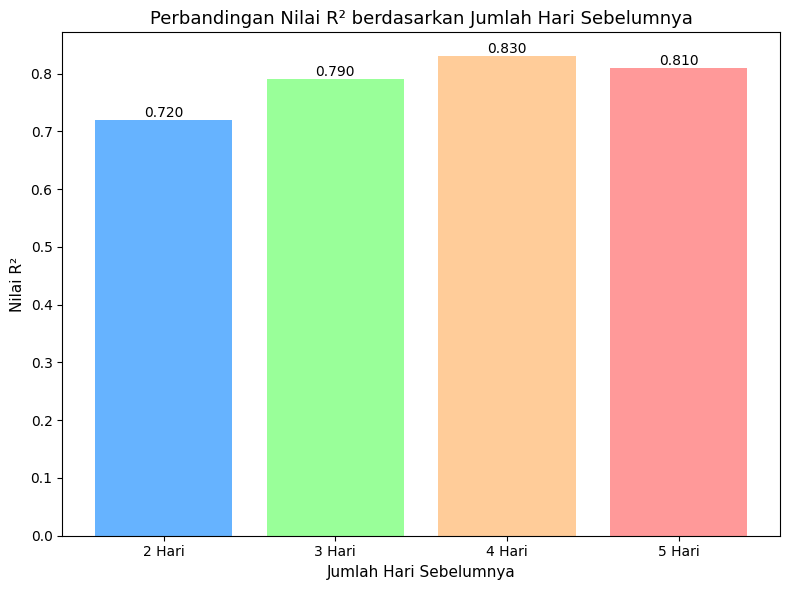

In [7]:


# Data hasil R² dari model (misalnya dari hasil prediksi hari 2–5)
r2_day2 = 0.72   # contoh nilai, ganti sesuai hasilmu
r2_day3 = 0.79
r2_day4 = 0.83
r2_day5 = 0.81

# Menyiapkan data untuk visualisasi
x = ['2 Hari', '3 Hari', '4 Hari', '5 Hari']
y = [r2_day2, r2_day3, r2_day4, r2_day5]

# Membuat plot batang
plt.figure(figsize=(8, 6))
bars = plt.bar(x, y, color=['#66b3ff', '#99ff99', '#ffcc99', '#ff9999'])

# Memberi judul dan label sumbu
plt.title("Perbandingan Nilai R² berdasarkan Jumlah Hari Sebelumnya", fontsize=13)
plt.xlabel("Jumlah Hari Sebelumnya", fontsize=11)
plt.ylabel("Nilai R²", fontsize=11)

# Menampilkan label nilai di atas batang
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()
